# Taller 2 - Red de Monitoreo de Calidad del Aire de Bogota.
http://rmcab.ambientebogota.gov.co/Report/stationreport

## Descripción de los datos 

## 1. Cargar Librerias
***

In [1]:
# Carga las librerias necesarias
import pandas as pd
import numpy as np
import matplotlib as plt
import matplotlib.pyplot as plt
import matplotlib as matplot
import seaborn as sns
from matplotlib.pyplot import figure
%matplotlib inline

## 2. Cargar Datos

In [68]:
#dataframe nombrado "df"
#Se usará el conjunto de datos "dataset_with_geo_missing" creado en el Taller 1, 
#este conjunto de datos, se caracteriza por no tener algunos valores.
 

 # carga el conjunto de datos ../Taller1/data/dataset_with_geo_missing.csv
 
df = pd.read_csv('data/dataset_with_geo_missing.csv', sep=',', engine='python', encoding='latin1')
df

,PM10,PM2.5,NO,NO2,NOX,CO,OZONO,Station,DateTime,Status,Latitud,Longitud,Name,Localidad,month,day_week,day_month,hour
0,56.6,32.7,7.504,15.962,23.493,0.44924,2.431,USM,2021-01-01 01:00:00,True,4.532097,-74.116947,usame,Usme,1,4,1,1
1,59.3,39.3,16.560,17.866,34.426,0.69832,1.121,USM,2021-01-01 02:00:00,True,4.532097,-74.116947,usame,Usme,1,4,1,2
2,96.4,70.8,22.989,17.802,40.791,0.88243,1.172,USM,2021-01-01 03:00:00,True,4.532097,-74.116947,usame,Usme,1,4,1,3
3,108.3,81.0,3.704,9.886,13.591,0.29549,6.565,USM,2021-01-01 04:00:00,True,4.532097,-74.116947,usame,Usme,1,4,1,4
4,87.7,56.1,2.098,9.272,11.371,0.16621,9.513,USM,2021-01-01 05:00:00,True,4.532097,-74.116947,usame,Usme,1,4,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166435,43.1,12.0,11.771,23.697,35.468,0.98779,8.146,KEN,2021-12-31 20:00:00,False,4.625083,-74.161222,kennedy,Kennedy,12,4,31,20
166436,35.0,35.0,6.634,21.677,28.311,0.85772,8.055,KEN,2021-12-31 21:00:00,True,4.625083,-74.161222,kennedy,Kennedy,12,4,31,21
166437,43.5,43.0,2.666,19.867,22.533,0.84339,6.877,KEN,2021-12-31 22:00:00,True,4.625083,-74.161222,kennedy,Kennedy,12,4,31,22
166438,60.1,55.0,2.622,19.689,22.311,0.84038,6.533,KEN,2021-12-31 23:00:00,True,4.625083,-74.161222,kennedy,Kennedy,12,4,31,23


## 3: Explorar datos
*** 

###  3.1 Estadisticas 
***
Resumen: 
- Identificar nombre de las columnas
- Número de columnas y filas 
- Tamaño del conjunto de datos
- Tipos de datos
- Porcentajes de valores
- Correlaciones de variables
- Valores nulos


In [3]:
# Estadisticas basicas del conjunto de datos 
df.describe()


,PM10,PM2.5,NO,NO2,NOX,CO,OZONO,Latitud,Longitud,month,day_week,day_month,hour
count,146426.000000,151128.000000,138776.000000,138778.000000,138772.000000,135202.000000,134308.000000,166440.000000,166440.000000,166440.000000,166440.000000,166440.000000,166440.000000
mean,31.978378,15.323489,18.616861,14.979247,33.590300,0.691233,11.782188,4.653331,-74.104733,6.526027,3.002740,15.720548,12.500000
std,22.835375,12.467040,26.932382,9.233824,30.056319,0.574689,10.133101,0.068116,0.039154,3.447862,1.997948,8.796273,6.922207
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.532097,-74.166272,1.000000,0.000000,1.000000,1.000000
25%,15.800000,6.000000,3.169000,7.515000,13.109000,0.324885,3.458000,4.595958,-74.143714,4.000000,1.000000,8.000000,6.750000
50%,26.700000,12.000000,7.759000,13.742000,24.259000,0.520580,9.564000,4.645117,-74.114869,7.000000,3.000000,16.000000,12.500000
75%,42.300000,21.600000,21.532000,20.626000,43.472250,0.862195,17.518250,4.710381,-74.069472,10.000000,5.000000,23.000000,18.250000
max,326.200000,188.000000,341.104000,92.256000,361.341000,12.025010,88.182000,4.783614,-74.030414,12.000000,6.000000,31.000000,24.000000


In [ ]:
#Descripción del conjunto de datos: 166440 observaciones y 18 caracteristicas
df.shape

(166440, 18)

In [5]:
# Comprobar el número de Filas y Columnas 
print("Número de  Filas: ", len(df))
print("Número de Columnas ", + len(df.columns))

#Comprobar el tipo de datos en las características
print(df.dtypes)

Número de  Filas:  166440
Número de Columnas  18
PM10         float64
PM2.5        float64
NO           float64
NO2          float64
NOX          float64
CO           float64
OZONO        float64
Station       object
DateTime      object
Status          bool
Latitud      float64
Longitud     float64
Name          object
Localidad     object
month          int64
day_week       int64
day_month      int64
hour           int64
dtype: object


In [10]:
#Comprobar si hay valores nulos true o false
df.isnull().any()


PM10          True
PM2.5         True
NO            True
NO2           True
NOX           True
CO            True
OZONO         True
Station      False
DateTime     False
Status       False
Latitud      False
Longitud     False
Name         False
Localidad    False
month        False
day_week     False
day_month    False
hour         False
dtype: bool

In [14]:
df.isnull().sum()

PM10         20014
PM2.5        15312
NO           27664
NO2          27662
NOX          27668
CO           31238
OZONO        32132
Station          0
DateTime         0
Status           0
Latitud          0
Longitud         0
Name             0
Localidad        0
month            0
day_week         0
day_month        0
hour             0
dtype: int64

In [15]:
rows_with_nulls = df[df.isnull().any(axis=1)]
print("Número de filas con valores nulos: ", len(rows_with_nulls))

Número de filas con valores nulos:  74803


In [13]:
# Esta celda eliminará todas las filas que tienen valores nulos
df_cleaned = df.dropna()
df_cleaned.isnull().any()
df_cleaned.shape


(91637, 18)

In [22]:
# Resumen de una variable (False V.S. True) en la variable Status
# La variable Status indica si el valor de PM2.5 está por encima o por debajo del umbral de seguridad
Status_Summary = df_cleaned.groupby('Status')
Status_Summary.mean(numeric_only=True)

,PM10,PM2.5,NO,NO2,NOX,CO,OZONO,Latitud,Longitud,month,day_week,day_month,hour
Status,,,,,,,,,,,,,
False,18.457214,5.985492,8.663330,11.977137,20.640284,0.451518,12.333248,4.655150,-74.099690,6.964393,3.041528,15.541579,12.701546
True,42.477894,23.314169,21.265807,20.143398,41.409216,0.787072,11.573096,4.647089,-74.115176,7.387008,2.990365,15.962375,12.381757


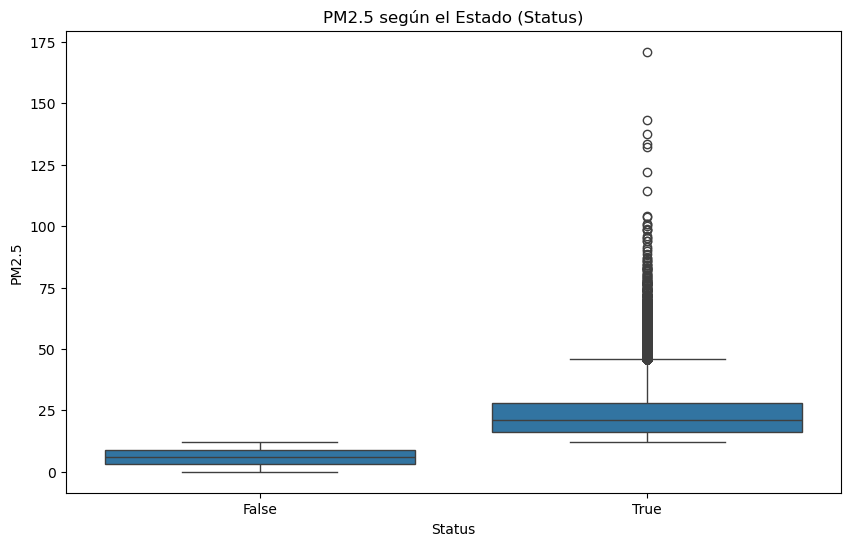

In [25]:
# Creamos un boxplot para visualizar la distribución de PM2.5 según el estado (Status)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Status', y='PM2.5', data=df_cleaned)
plt.title('PM2.5 según el Estado (Status)')
plt.show()

In [26]:
#Filtrar datos por columnas
df_cleaned['Status'] = df_cleaned['PM2.5']>12
df_cleaned['Status'].value_counts()

/tmp/ipykernel_1577/703010552.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Status'] = df_cleaned['PM2.5']>12


Status
False    48979
True     42658
Name: count, dtype: int64

####  3.1.1 Correlación
***

Resumen:


- Hay una correlación **positiva(+) a 1** o **negativa(-) a -1** hay una correlacion fuerte. La aproximación a 0 es mas debil la relacion lineal  

<Axes: >

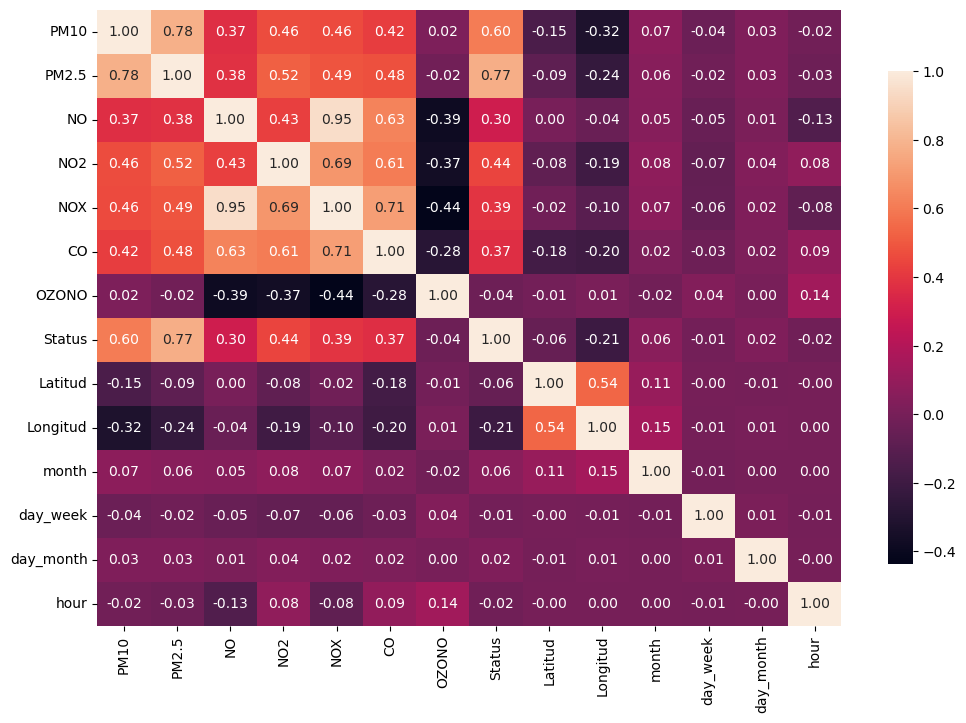

In [38]:
#Matriz de correlación

# Seleccionamos solo las columnas numéricas para calcular la correlación
corr = df_cleaned.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(corr, 
            xticklabels=corr.columns.values,
            yticklabels=corr.columns.values,
            fmt=".2f",
            cbar_kws={"shrink": .8},
            annot=True)

In [35]:
print(corr)

               PM10     PM2.5        NO       NO2       NOX        CO  \
PM10       1.000000  0.779057  0.369648  0.463767  0.457725  0.417326   
PM2.5      0.779057  1.000000  0.379350  0.522830  0.486106  0.475095   
NO         0.369648  0.379350  1.000000  0.425175  0.948787  0.628080   
NO2        0.463767  0.522830  0.425175  1.000000  0.689339  0.606528   
NOX        0.457725  0.486106  0.948787  0.689339  1.000000  0.714405   
CO         0.417326  0.475095  0.628080  0.606528  0.714405  1.000000   
OZONO      0.019623 -0.017234 -0.385378 -0.366649 -0.436430 -0.280863   
Status     0.603773  0.772021  0.297139  0.441555  0.391945  0.367937   
Latitud   -0.151311 -0.088338  0.004448 -0.081281 -0.024804 -0.179931   
Longitud  -0.323000 -0.237425 -0.043740 -0.189655 -0.101204 -0.196739   
month      0.071172  0.056471  0.047358  0.078563  0.065326  0.018566   
day_week  -0.041897 -0.024650 -0.051813 -0.066934 -0.064831 -0.032497   
day_month  0.028028  0.026535  0.014017  0.036441  

###  3.2 Gráficos de distribución 


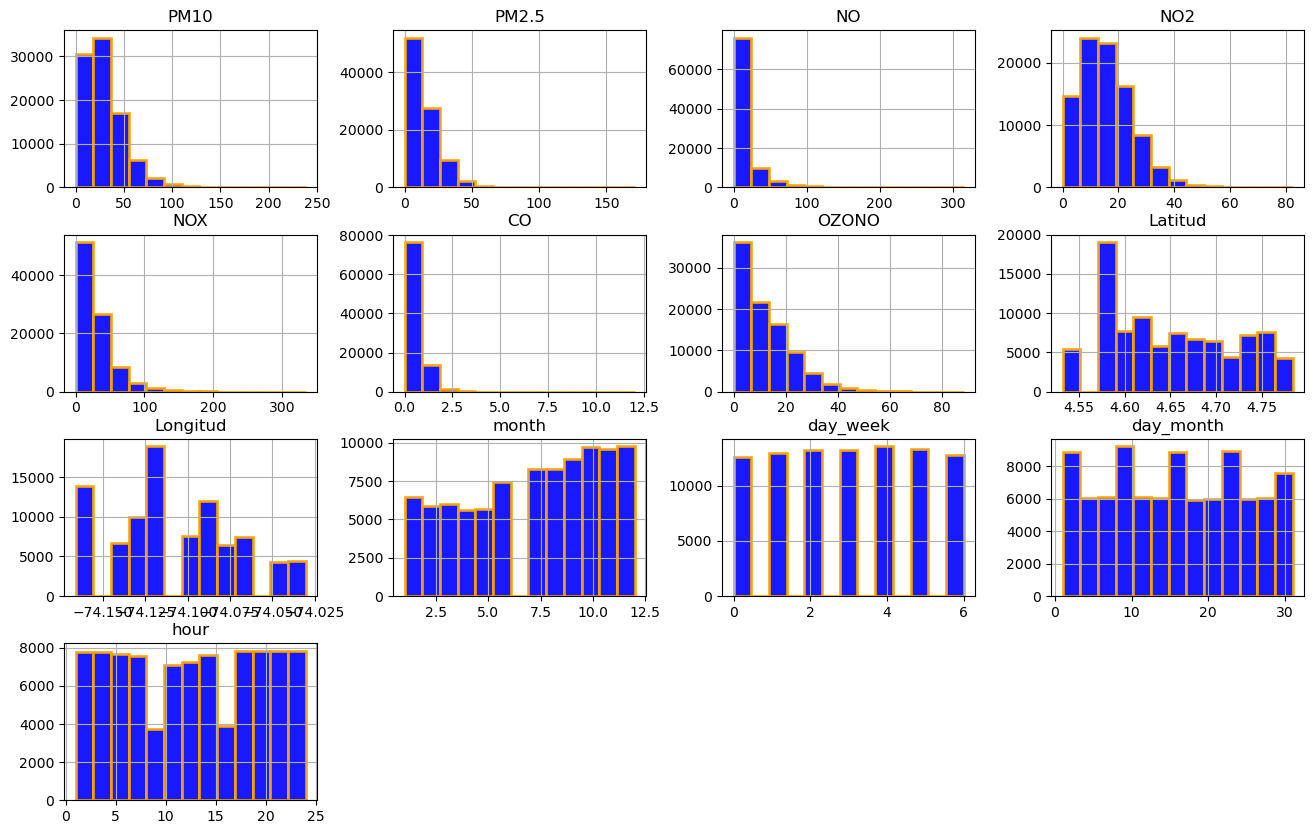

In [43]:
#hist es un grafico (pandas) de distribucion de  datos.
#este grafico nos sirve para identificar cuales son las variables numericas y su frencuencia. 

df_cleaned.hist(figsize=(16,10),facecolor='blue', alpha=0.9, bins=13, edgecolor='orange', linewidth=2)
plt.show()

/tmp/ipykernel_1577/3198926302.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_cleaned.PM10, kde=False, color="g", ax=axes[0]).set_title('PM10')
/tmp/ipykernel_1577/3198926302.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_cleaned.Status, kde=False, color="r", ax=axes[1]).set_titl

Text(0.5, 1.0, 'NOX')

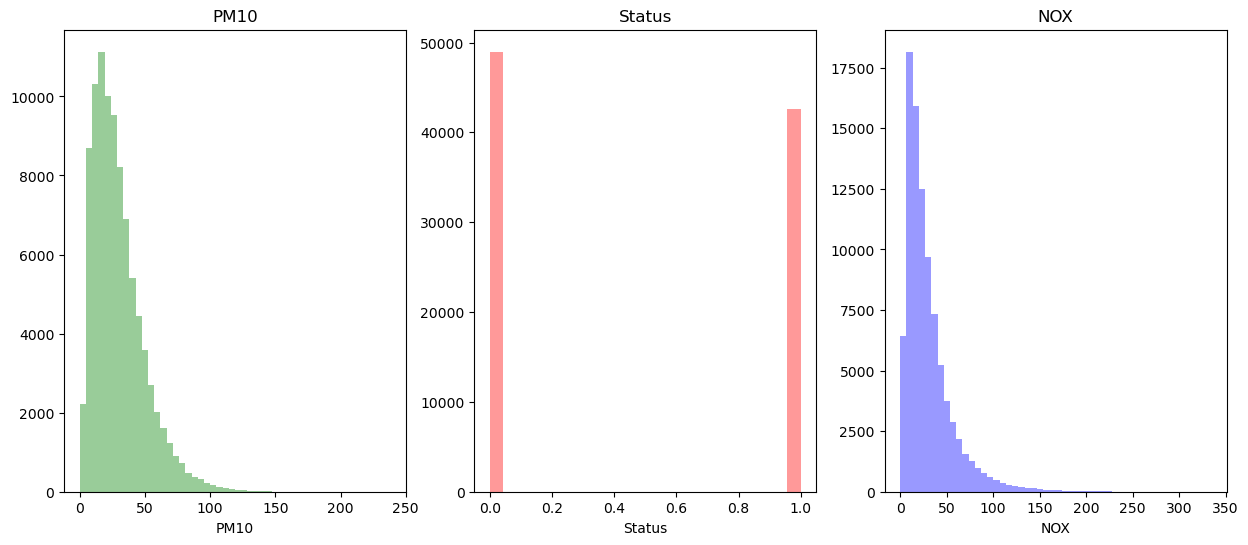

In [44]:
#otra forma de ver la distribucion de los datos
# Uso de Libreria Seaborn (sna) para poner multiples graficos de distribución  
f, axes = plt.subplots(ncols=3, figsize=(15, 6))

#variable PM10
sns.distplot(df_cleaned.PM10, kde=False, color="g", ax=axes[0]).set_title('PM10')

#variable PM10
sns.distplot(df_cleaned.Status, kde=False, color="r", ax=axes[1]).set_title('Status')

#variable NOX
sns.distplot(df_cleaned.NOX, kde=False, color="b", ax=axes[2]).set_title('NOX')

###  3.3 Gráfico de barras


Text(0.5, 1.0, 'Distribución de Station')

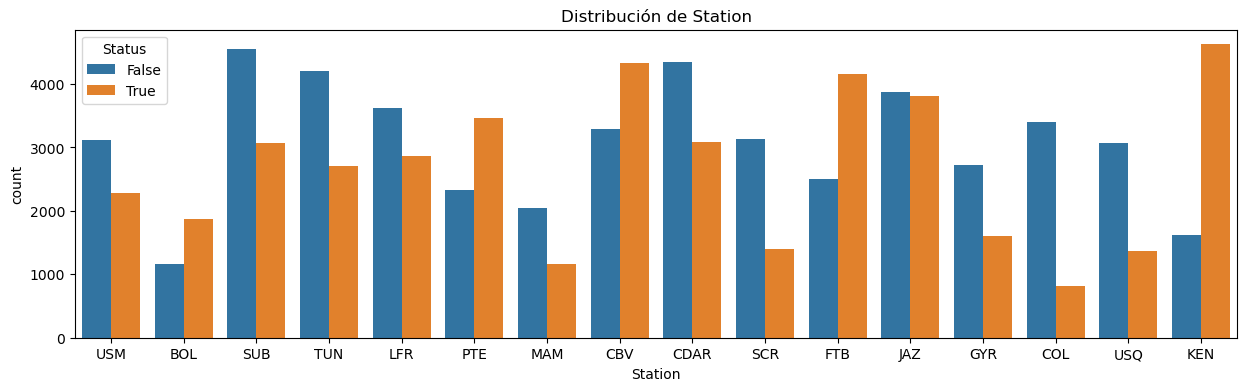

In [50]:
#ditribucion por estacion 
f, ax = plt.subplots(figsize=(15, 4))
sns.countplot(x="Station", hue='Status', data=df_cleaned).set_title('Distribución de Station')

/tmp/ipykernel_1577/2663872389.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Station', data=df_cleaned, palette=color_types).set_title('Distribución por Estación')


(array([   0., 1000., 2000., 3000., 4000., 5000., 6000., 7000., 8000.,
        9000.]),
 [Text(0.0, 0, '0'),
  Text(1000.0, 0, '1000'),
  Text(2000.0, 0, '2000'),
  Text(3000.0, 0, '3000'),
  Text(4000.0, 0, '4000'),
  Text(5000.0, 0, '5000'),
  Text(6000.0, 0, '6000'),
  Text(7000.0, 0, '7000'),
  Text(8000.0, 0, '8000'),
  Text(9000.0, 0, '9000')])

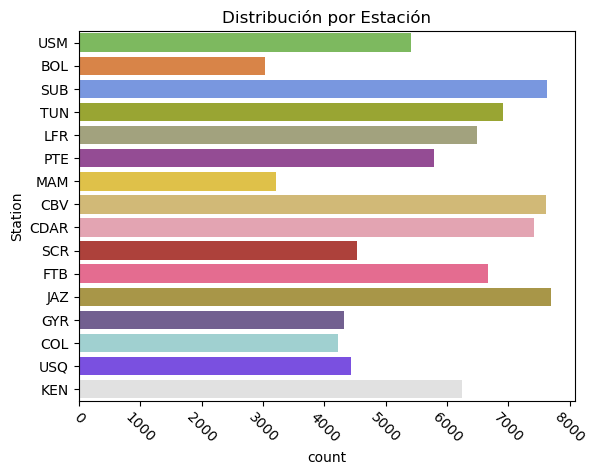

In [57]:
# Types of colors
color_types = ['#78C850','#F08030','#6890F0','#A8B820','#A8A878','#A040A0','#F8D030',  
                '#E0C068','#EE99AC','#C03028','#F85888','#B8A038','#705898','#98D8D8','#7038F8' ,'#E1E1E1']

# Count Plot (a.k.a. Bar Plot)
sns.countplot(y='Station', data=df_cleaned, palette=color_types).set_title('Distribución por Estación')
 
# Rotate x-labels
plt.xticks(rotation=-45)

###  3.4 Gráficos de Cajas


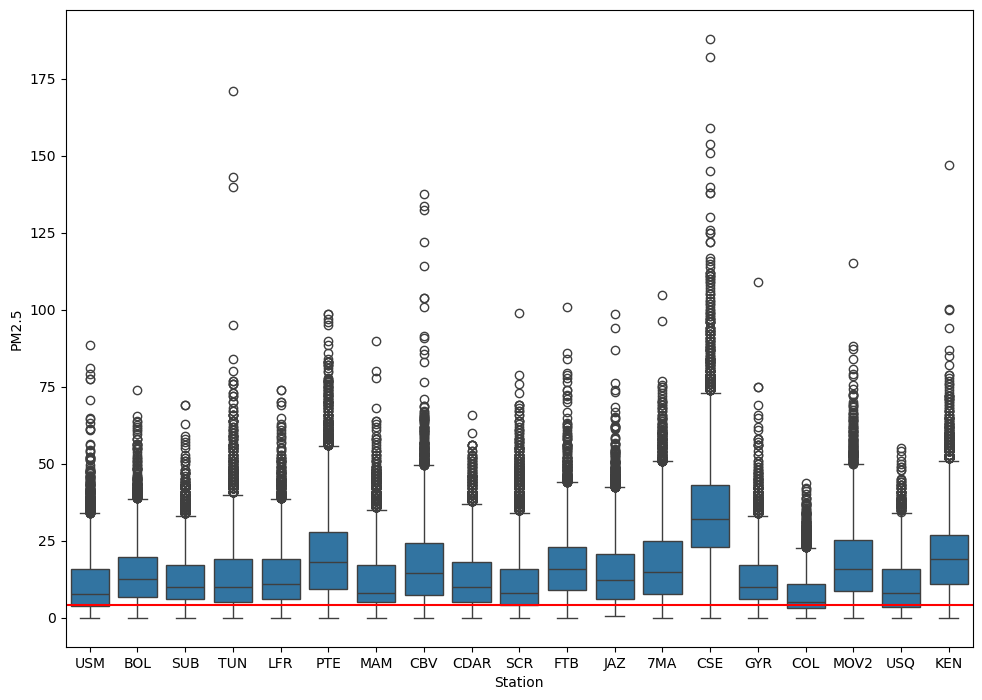

In [58]:

a4_dims = (11.7, 8.27)
fig, ax = plt.subplots(figsize=a4_dims)

sns.boxplot(x="Station", y="PM2.5",  data=df)
valh=4
plt.axhline(valh, color='red')

Hemos revisado la información de ded dataset "calidad del aire", donde es importante la estación que mide la calidad del aire, sin embargo, no tenemos donde esta ubicada. 

Ahora vamos a cargar un nuevo dataset, que contiene la infromación de la ubicación (Latitud, Longitud) de cada estación.

## 4. Tecnicas para solucionar valores perdidos y anomalias en un dataset

In [59]:
#Contar valores nulos por columnas
df.isnull().sum()



PM10         20014
PM2.5        15312
NO           27664
NO2          27662
NOX          27668
CO           31238
OZONO        32132
Station          0
DateTime         0
Status           0
Latitud          0
Longitud         0
Name             0
Localidad        0
month            0
day_week         0
day_month        0
hour             0
dtype: int64

### 4.1 Completar con la media, mediana o desviación estándar

In [63]:
#Para todo el conjunto de datos 
df_1 = df.fillna(df.std(numeric_only=True))
df_1.isnull().sum()

PM10         0
PM2.5        0
NO           0
NO2          0
NOX          0
CO           0
OZONO        0
Station      0
DateTime     0
Status       0
Latitud      0
Longitud     0
Name         0
Localidad    0
month        0
day_week     0
day_month    0
hour         0
dtype: int64

In [71]:
#Para una sola columna

df_2 = df.copy() 
df_2['PM10'].fillna((df['PM10'].std()), inplace=True)
df_2.isnull().sum()


PM10             0
PM2.5        15312
NO           27664
NO2          27662
NOX          27668
CO           31238
OZONO        32132
Station          0
DateTime         0
Status           0
Latitud          0
Longitud         0
Name             0
Localidad        0
month            0
day_week         0
day_month        0
hour             0
dtype: int64

### 4.2 Completar con valor predeterminada 

In [73]:
df_3 = df.fillna(25)
df_3.isnull().sum()
df_3.iloc[20]

PM10                        20.0
PM2.5                        3.7
NO                         6.701
NO2                       10.722
NOX                       17.423
CO                          25.0
OZONO                      9.854
Station                      USM
DateTime     2021-01-01 21:00:00
Status                     False
Latitud                 4.532097
Longitud              -74.116947
Name                       usame
Localidad                   Usme
month                          1
day_week                       4
day_month                      1
hour                          21
Name: 20, dtype: object

### 4.3 Eliminar NaN

In [74]:
#Elinina todas las filas que tengan NaN
df_4 = df.dropna()

In [75]:
df_4.isnull().sum()

PM10         0
PM2.5        0
NO           0
NO2          0
NOX          0
CO           0
OZONO        0
Station      0
DateTime     0
Status       0
Latitud      0
Longitud     0
Name         0
Localidad    0
month        0
day_week     0
day_month    0
hour         0
dtype: int64